In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("Uber_Cleaned.csv")

In [6]:
df.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Hour,Time
0,619,Airport,1.0,Trip Completed,11-07-2016 11:51,11-07-2016 13:00,11,Morning
1,867,Airport,1.0,Trip Completed,11-07-2016 17:57,11-07-2016 18:47,17,Evening
2,1807,City,1.0,Trip Completed,12-07-2016 09:17,12-07-2016 09:58,9,Morning
3,2532,Airport,1.0,Trip Completed,12-07-2016 21:08,12-07-2016 22:03,21,Night
4,3112,City,1.0,Trip Completed,13-07-2016 08:33,13-07-2016 09:25,8,Early Morning


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
 6   Hour               6745 non-null   int64  
 7   Time               6745 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 421.7 KB


In [8]:
df.describe()

,Request id,Driver id,Hour
count,6745.000000,4095.000000,6745.000000
mean,3384.644922,149.501343,12.956709
std,1955.099667,86.051994,6.504052
min,1.000000,1.000000,0.000000
25%,1691.000000,75.000000,7.000000
50%,3387.000000,149.000000,13.000000
75%,5080.000000,224.000000,19.000000
max,6766.000000,300.000000,23.000000


In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
 6   Hour               6745 non-null   int64  
 7   Time               6745 non-null   str    
dtypes: float64(1), int64(2), str(5)
memory usage: 421.7 KB


In [10]:
df.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
Hour                    0
Time                    0
dtype: int64

In [11]:
df.describe()

,Request id,Driver id,Hour
count,6745.000000,4095.000000,6745.000000
mean,3384.644922,149.501343,12.956709
std,1955.099667,86.051994,6.504052
min,1.000000,1.000000,0.000000
25%,1691.000000,75.000000,7.000000
50%,3387.000000,149.000000,13.000000
75%,5080.000000,224.000000,19.000000
max,6766.000000,300.000000,23.000000


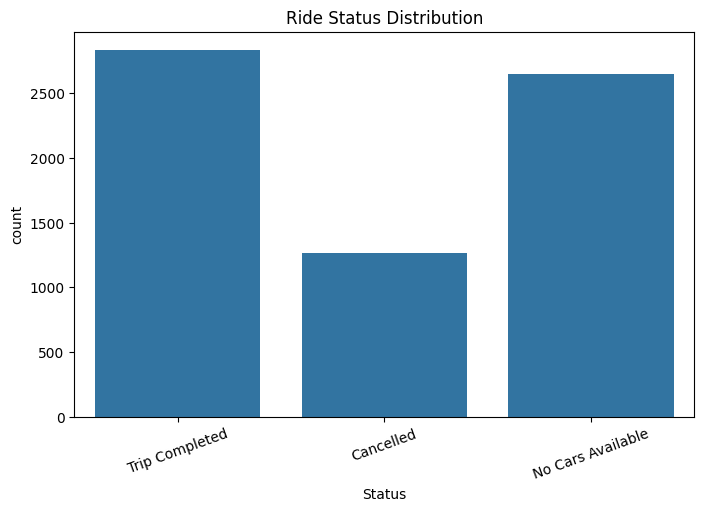

In [24]:
# Objective:
# 1. Analyze the overall distribution of ride statuses
# 2. Compare completed, cancelled, and unavailable rides
# 3. Identify major service issues affecting ride completion

plt.figure(figsize=(8,5))

sns.countplot(x='Status', data=df)

plt.title("Ride Status Distribution")
plt.xticks(rotation=20)

plt.show()

# Insights:
# 1. Most ride requests are either completed or marked as "No Cars Available"
# 2. Cancelled rides are comparatively lower than other ride statuses
# 3. A high number of "No Cars Available" cases indicates supply-demand imbalance
# 4. Ride availability appears to be a major operational challenge

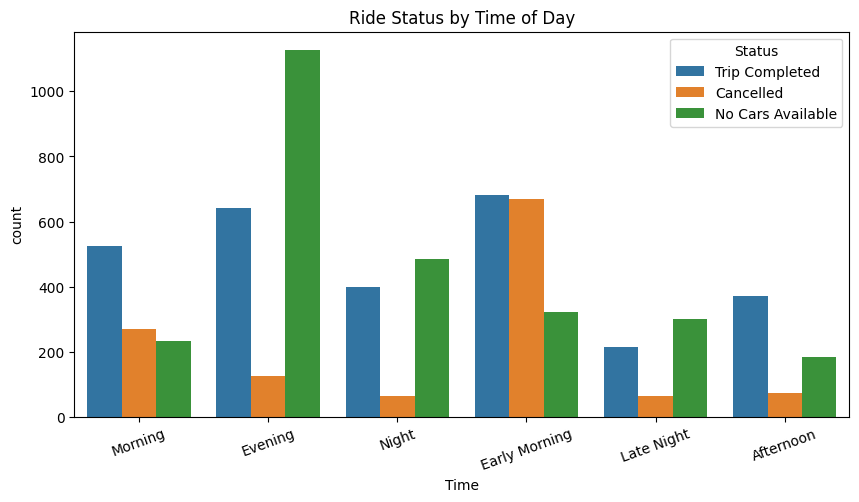

In [25]:
# Objective:
# 1. Analyze ride demand patterns across different time periods
# 2. Identify peak hours for cancellations and "No Cars Available" cases
# 3. Understand how ride availability changes throughout the day

plt.figure(figsize=(10,5))

sns.countplot(x='Time', hue='Status', data=df)

plt.title("Ride Status by Time of Day")
plt.xticks(rotation=20)

plt.show()

# Insights:
# 1. "No Cars Available" cases are highest during Evening hours
# 2. Ride cancellations are more frequent during Morning hours
# 3. Trip completions remain relatively strong throughout the day
# 4. Demand appears to exceed driver availability during peak office timings

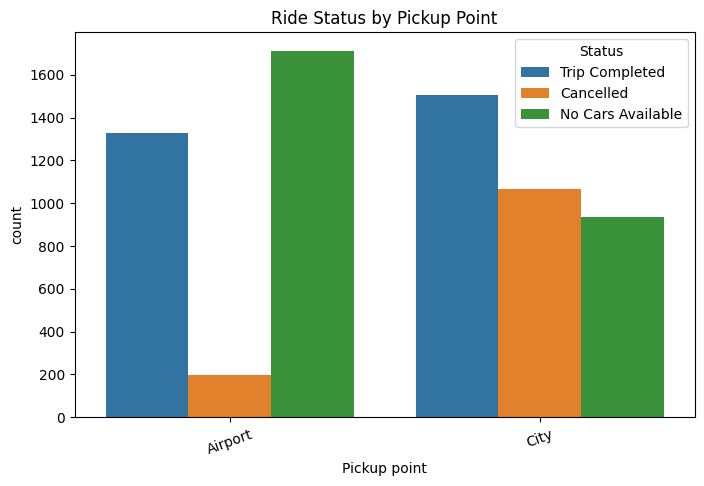

In [26]:
# Objective:
# 1. Compare ride issues between Airport and City pickup points
# 2. Identify where "No Cars Available" occurs most frequently
# 3. Analyze operational inefficiencies based on pickup location

plt.figure(figsize=(8,5))

sns.countplot(x='Pickup point', hue='Status', data=df)

plt.title("Ride Status by Pickup Point")
plt.xticks(rotation=20)

plt.show()

# Insights:
# 1. Airport pickups show a high number of "No Cars Available" cases
# 2. City pickups experience more ride cancellations compared to Airport pickups
# 3. Trip completions are relatively balanced across both pickup points
# 4. Different pickup locations face different operational challenges

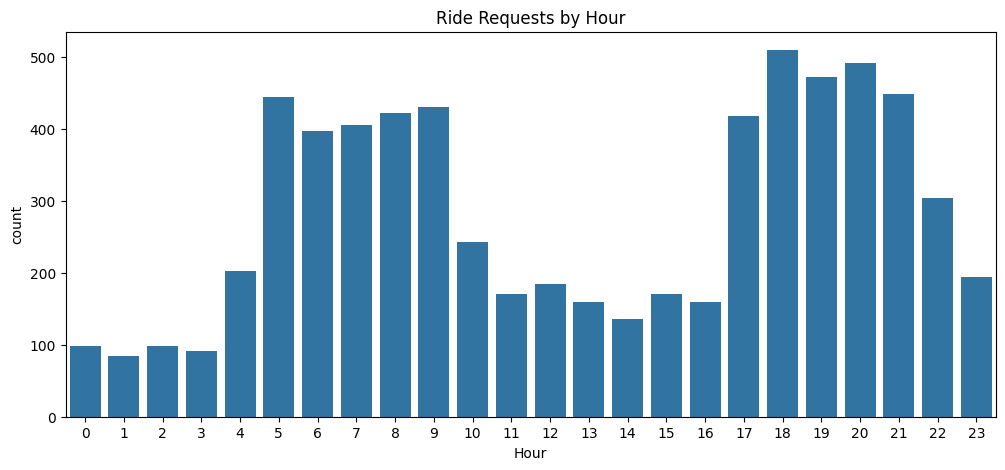

In [27]:
# Objective:
# 1. Identify peak ride request hours
# 2. Analyze customer demand throughout the day
# 3. Understand hourly traffic patterns for ride requests

plt.figure(figsize=(12,5))

sns.countplot(x='Hour', data=df)

plt.title("Ride Requests by Hour")

plt.show()

# Insights:
# 1. Ride requests peak during morning office hours (5–9 AM)
# 2. Another major demand spike occurs during evening hours (5–9 PM)
# 3. Ride demand is relatively lower during late night hours
# 4. Customer demand strongly follows daily office commute patterns

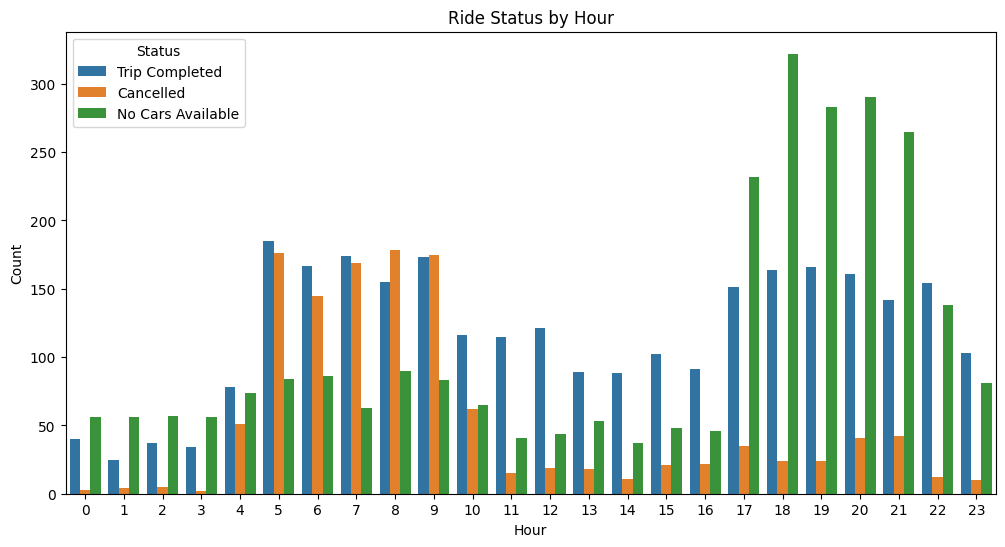

In [28]:
# Objective:
# 1. Analyze ride status trends across different hours of the day
# 2. Identify hours with highest cancellations and unavailable rides
# 3. Detect supply-demand imbalance during peak timings

plt.figure(figsize=(12,6))

sns.countplot(x='Hour', hue='Status', data=df)

plt.title("Ride Status by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")

plt.show()

# Insights:
# 1. Ride cancellations peak during early morning office hours
# 2. "No Cars Available" cases rise sharply during evening hours
# 3. Evening demand significantly exceeds driver availability
# 4. Uber faces supply-demand imbalance during peak commute timings

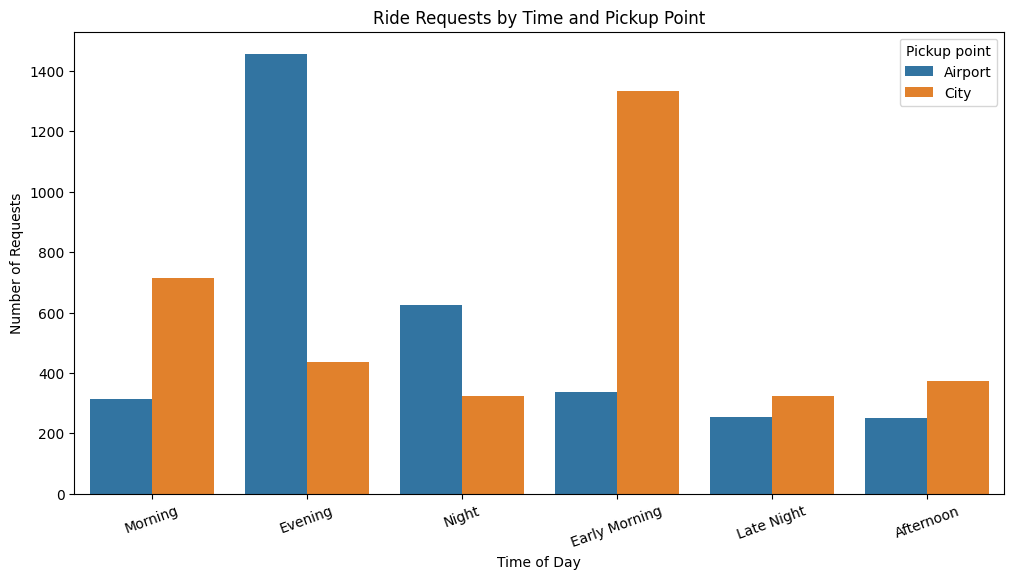

In [29]:
# Objective:
# 1. Analyze ride demand across pickup points and time periods
# 2. Identify busiest pickup locations during peak hours
# 3. Understand customer demand behavior throughout the day

plt.figure(figsize=(12,6))

sns.countplot(x='Time', hue='Pickup point', data=df)

plt.title("Ride Requests by Time and Pickup Point")
plt.xlabel("Time of Day")
plt.ylabel("Number of Requests")

plt.xticks(rotation=20)

plt.show()

# Insights:
# 1. Airport ride requests are higher during Evening and Night hours
# 2. City ride requests are more frequent during Morning office hours
# 3. Demand patterns vary significantly between Airport and City locations
# 4. Peak demand periods align with common travel and office commute timings

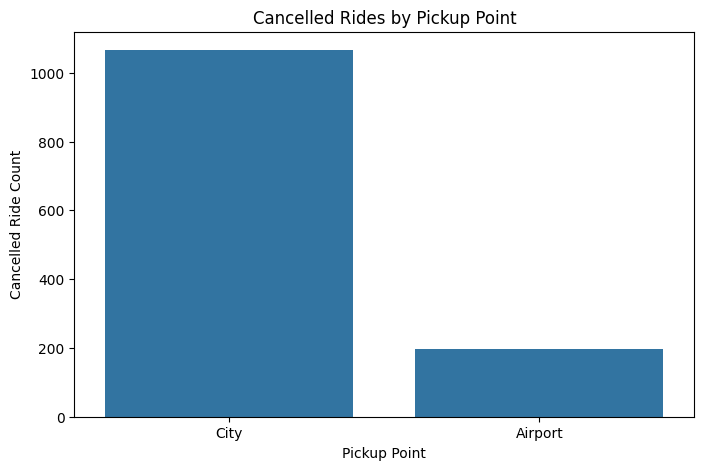

In [30]:
# Objective:
# 1. Analyze cancellation patterns across pickup locations
# 2. Identify which pickup point experiences more cancellations
# 3. Understand operational challenges related to ride cancellations

plt.figure(figsize=(8,5))

cancelled_df = df[df['Status'] == 'Cancelled']

sns.countplot(x='Pickup point', data=cancelled_df)

plt.title("Cancelled Rides by Pickup Point")
plt.xlabel("Pickup Point")
plt.ylabel("Cancelled Ride Count")

plt.show()

# Insights:
# 1. City pickup points experience more ride cancellations than Airport pickups
# 2. Customer cancellations may be linked to longer waiting times in the City
# 3. Airport ride operations appear comparatively more stable
# 4. Improving driver allocation in City areas may reduce cancellations

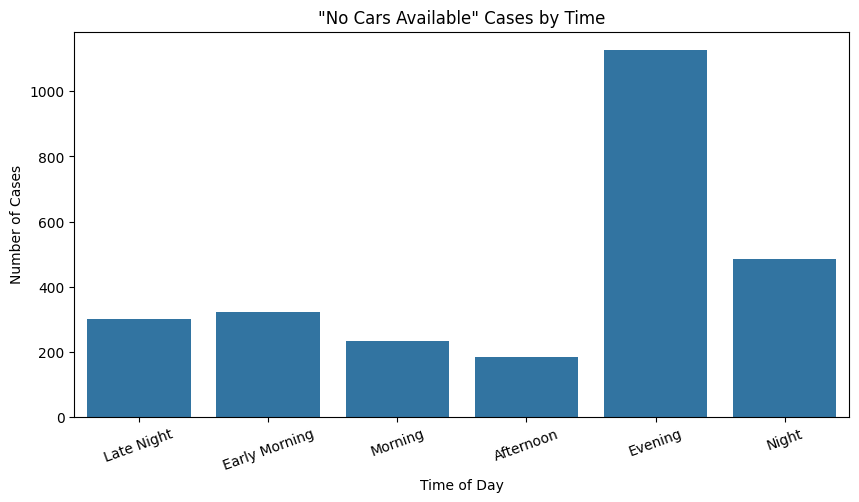

In [31]:
# Objective:
# 1. Analyze when customers face cab unavailability the most
# 2. Identify peak time periods for supply shortages
# 3. Understand Uber’s supply-demand imbalance across the day

plt.figure(figsize=(10,5))

no_cars_df = df[df['Status'] == 'No Cars Available']

sns.countplot(x='Time', data=no_cars_df)

plt.title('"No Cars Available" Cases by Time')
plt.xlabel("Time of Day")
plt.ylabel("Number of Cases")

plt.xticks(rotation=20)

plt.show()

# Insights:
# 1. "No Cars Available" cases are highest during Evening hours
# 2. Uber experiences severe supply shortages during peak commute timings
# 3. Evening demand significantly exceeds available driver supply
# 4. Improving driver availability during Evening and Night hours may reduce ride failures

In [ ]:
# Final Conclusion

From the analysis, it is clear that Uber faces a significant supply-demand gap during peak office commute hours.

The Evening time slot shows the highest number of "No Cars Available" cases, indicating that customer demand exceeds driver availability during this period.

Ride cancellations are more common during Morning hours, especially for City pickup points.

Airport and City locations show different operational challenges:
- Airport requests experience higher cab unavailability
- City requests experience more cancellations

Overall, Uber needs better driver allocation and improved availability during high-demand hours to reduce ride failures and improve customer satisfaction.

In [ ]:
# Business Recommendations

1. Increase driver availability during Evening and Night hours to reduce "No Cars Available" cases.

2. Provide incentives to drivers during Morning peak hours to reduce ride cancellations.

3. Implement dynamic pricing during high-demand periods to balance supply and demand.

4. Improve driver allocation strategies separately for Airport and City pickup locations.

5. Introduce shift-based driver scheduling during office commute timings.